# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
url = "https://raw.githubusercontent.com/abdlsykr/portfolio/refs/heads/main/Dicoding/Belajar_Machine_Learning_Untuk_Pemula/clustering_results.csv"
df = pd.read_csv(url)

print(df.head())

  TransactionID AccountID  TransactionAmount      TransactionDate  \
0      TX000001   AC00128              14.09  2023-04-11 16:29:14   
1      TX000002   AC00455             376.24  2023-06-27 16:44:19   
2      TX000003   AC00019             126.29  2023-07-10 18:16:08   
3      TX000004   AC00070             184.50  2023-05-05 16:32:11   
4      TX000005   AC00411              13.45  2023-10-16 17:51:24   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0           70             Doctor                   81 

# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [3]:
X = df[['TransactionAmount', 'AccountBalance', 'CustomerAge']]  # Fitur yang digunakan
y = df['Cluster']  # Target variable (cluster yang sudah ditentukan)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [4]:
# Membangun model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih model menggunakan data latih
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Random Forest** adalah algoritma ensemble yang menggabungkan beberapa pohon keputusan untuk meningkatkan akurasi. Setiap pohon dibuat dengan memilih subset acak dari fitur, dan hasil prediksi diperoleh dengan mayoritas suara dari seluruh pohon. Keunggulannya adalah kemampuan untuk menangani data yang besar dengan baik dan memberikan hasil yang lebih akurat.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.54      0.69      0.61       106
           2       0.85      0.80      0.82       258
           3       0.98      0.95      0.96       129

    accuracy                           0.80       503
   macro avg       0.59      0.61      0.60       503
weighted avg       0.80      0.80      0.80       503



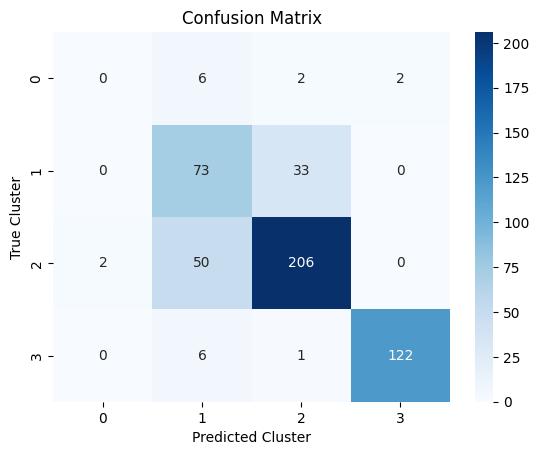

In [5]:
# Prediksi pada data uji
y_pred = model.predict(X_test)

# Menghitung accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Menampilkan laporan klasifikasi (precision, recall, F1-score)
print(classification_report(y_test, y_pred))

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Cluster')
plt.show()


## **c. Tuning Model Klasifikasi (Optional)**

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

### 1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).


### 2. Identifikasi kelemahan model, seperti:


*   **Cluster 0** mengalami performa yang sangat buruk (precision dan recall = 0.00). Model tidak mampu mengenali data dari cluster ini, kemungkinan besar karena jumlah data yang sangat sedikit (hanya 10 sampel).
*   **Cluster 1** memiliki precision 0.54 dan recall 0.69, artinya terdapat kesalahan prediksi cukup banyak, dengan 33 data dari Cluster 1 salah diprediksi menjadi Cluster 2.
*   **Cluster 2** memperlihatkan performa yang cukup baik dengan precision 0.85 dan recall 0.80, meski ada 50 data dari Cluster 2 yang salah diklasifikasikan sebagai Cluster 1.
*   **Cluster 3** menunjukkan performa sangat tinggi dengan precision 0.98 dan recall 0.95, di mana hanya sedikit data yang salah klasifikasi.


### 3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.


*   Menambah jumlah data untuk Cluster 0 atau mempertimbangkan mengeliminasi cluster tersebut jika memang populasinya sangat kecil dan kurang relevan.
*   Melakukan balancing dataset, seperti oversampling pada cluster minoritas atau undersampling cluster mayoritas.
*   Mencoba algoritma klasifikasi lain seperti XGBoost, atau Neural Network untuk melihat apakah performa bisa lebih baik.
*   Melakukan tuning untuk meningkatkan performa, khususnya dalam membedakan Cluster 1 dan Cluster 2.
*   Menambah atau mengoptimalkan fitur yang bisa membantu model memisahkan cluster lebih akurat.










